Приближаемся к более реалистичному сеттингу.

Ранее контроллер располагал состоянием агентов $s(t) = \begin{pmatrix} x(t) \\ v(t) \end{pmatrix} \in \mathbb{R}^2$. Сейчас агенты будут посылать сигналы чтобы узнать расстояние между собой (пока пусть мы сохраним абсолютные величины, относительность достижима простым сдвигом). То есть скорость они будут оценивать.

Пока действуем в предположении, что за $\Delta t$ все агенты способны узнать расстояния между соседями, ограничения будут ниже.

Оказывается, наше текущее решение накапливает в себе ошибку, что уже с первых секунд плохо сказывается на агентов в хвосте.

Наивную оценку скорости агента $i$ строим приближением траектории движения квадратичным многочленом (будет ошибка порядка $\mathcal{O}(\Delta t^2)$)

Для удобства временно переобозначим точки. К $k$-му шагу прошло $k \Delta t$ секунд, тогда для некоторой идеальной гладкой траектории движения $x_i (t)$ обозначаем $$x_k := x_i (k \Delta t), \quad x_{k-1} := x_i (k \Delta t - \Delta t), \quad x_{k-2} := x_i (k \Delta t - 2\Delta t)$$ Но полином $p(\tau) = A \tau^2 + B \tau + C$ делаем от переменной сдвига, а не абсолютного времени, так
$$p(0) = x_k \quad p(-\Delta t) = x_{k-1} \quad p(-2 \Delta t) = x_{k-2}$$
 Получаем систему:
\begin{cases}
p(0)=C=x_k\\
p(-\Delta t)=A(\Delta t)^2-B\Delta t+C=x_{k-1}\\
p(-2\Delta t)=4A(\Delta t)^2-2B \Delta t+C=x_{k-2}
 ​\end{cases}

 Решаем ее $$v_i (k \Delta t) = v_k \approx \dot{p} (0) = B = \frac{3 x_k - 4 x_{k-1} + x_{k-2} }{2 \Delta t}$$

Аналогично (но с большей степенью полинома) приближаем ускорение:

$$a_i (k \Delta t) \approx \frac{2x_k - 5x_{k-1} + 4x_{k-2} - x_{k-3}}{2 \Delta t ^ 2}$$
В начале при отсутствии истории 3-х последних шагов: $v_i (k \Delta t) \approx \frac{x_k - x_{k-1}}{\Delta t} , \quad a_i (k \Delta t) \approx \frac{v_k - v_{k-1}}{\Delta t} $

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from typing import Tuple, List
import itertools
import math

In [ ]:
class Swarm:
    def __init__(self, start_positions: np.ndarray, start_velocities: np.ndarray, dt: float, hist_len: int = 3):
        assert start_positions.shape == start_velocities.shape
        assert len(start_positions.shape) == 1

        self.x = np.copy(start_positions)
        self.v = np.copy(start_velocities)
        self.N = len(start_positions)
        self.t = 0.0
        self.dt = dt
        self.trajectory = [(self.t, self.x.copy())]

        self.hist = deque([self.x.copy()], maxlen=hist_len)

    def estimate_v_a(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Estimate velocity and acceleration from position history.
        - At t=0: returns (v₀, 0)
        - At t=1*dt: uses 1st-order FD for v, a=0
        - At t>=2*dt: uses 2nd-order backward FD for v, 1st-order for a (or 2nd if enough history)
        Safe, causal, no crashes.
        """
        x_now = self.x
        past_x = list(self.hist)[1:]  # [x(t-dt), x(t-2dt), ...]

        if len(past_x) == 0:
            # t = 0: no history → use initial v, a = 0
            return self.v.copy(), np.zeros(self.N)

        elif len(past_x) == 1:
            # t = dt: one past point → 1st-order v, a = 0
            x_prev = past_x[0]
            v_est = (x_now - x_prev) / self.dt
            a_est = np.zeros(self.N)
            return v_est, a_est

        else:
            x_t1 = past_x[0]   # x(t - dt)
            x_t2 = past_x[1]   # x(t - 2dt)
            v_est = (3*x_now - 4*x_t1 + x_t2) / (2 * self.dt)
            if len(past_x) >= 3:
                x_t3 = past_x[2]
                a_est = (2*x_now - 5*x_t1 + 4*x_t2 - x_t3) / (2 * self.dt**2)
            else:
                v_prev = (x_t1 - x_t2) / self.dt
                a_est = (v_est - v_prev) / self.dt
            return v_est, a_est

    def step(self, dt_accelerations: np.ndarray):
        self.x = self.x + self.v * self.dt + 0.5 * dt_accelerations * self.dt**2
        self.v = self.v + dt_accelerations * self.dt
        self.t += self.dt
        self.trajectory.append((self.t, self.x.copy()))

        self.hist.appendleft(self.x.copy())

In [ ]:
class SMDSimpleController:
    def __init__(self, m: float, a_max: float, v_d: float, s_0: float, dt: float):
        self.m = m
        self.a_max = a_max
        self.v_d = v_d
        self.s_0 = s_0
        self.dt = dt
        self.c = self.m * self.a_max / self.v_d

    def control_step(self, swarm: Swarm) -> np.ndarray:
        # Estimate v (and a, if needed) from swarm’s *internal* history
        v_est, _ = swarm.estimate_v_a()
        x = swarm.x

        accs = np.zeros(len(x))
        N = len(x)

        # Alpha (last vehicle): speed regulation
        accs[-1] = self.c / self.m * (self.v_d - v_est[-1])

        # Others: spacing + damping
        for i in range(N - 1):
            ell_i = self.s_0 + self.dt * v_est[i]
            k_i = self.m * self.a_max / ell_i
            b_i = max(self.m / self.dt, np.sqrt(k_i * self.m))
            accs[i] = (k_i * (x[i+1] - x[i] - ell_i) + b_i * (v_est[i+1] - v_est[i])) / self.m
        return accs

In [ ]:
def cyclogram(swarm, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    times = np.array([t for t, _ in swarm.trajectory])
    positions = np.array([x for _, x in swarm.trajectory])

    for i in range(positions.shape[1]):
        label = f"Alpha" if i == positions.shape[1] - 1 else f"{i+1}"
        ax.plot(times, positions[:, i], label=label, marker='o', markersize=3)

    ax.set_xlabel('Time $t$ [s]')
    ax.set_ylabel('Position $x$ [m]')
    ax.set_title('Cyclogram: Agent Trajectories')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()
    return ax

/tmp/ipython-input-3359559294.py:25: RuntimeWarning: invalid value encountered in sqrt
  b_i = max(self.m / self.dt, np.sqrt(k_i * self.m))


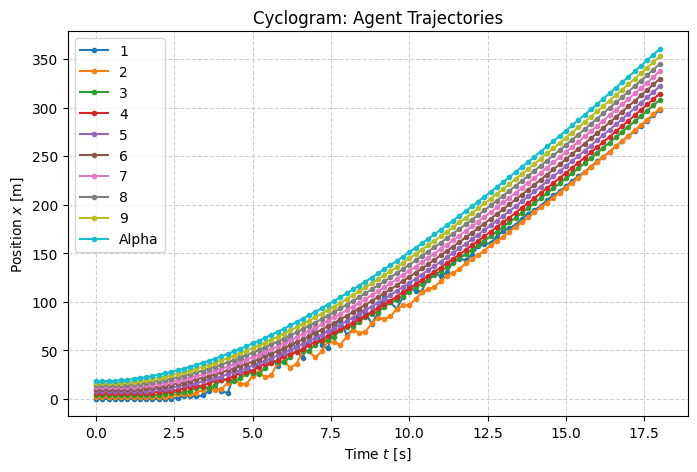

In [ ]:
N = 10
s_0 = 2.0
x0 = np.arange(0, N * s_0, s_0)
v0 = np.zeros(N)
dt = 0.2

swarm = Swarm(x0, v0, dt, hist_len=3)
controller = SMDSimpleController(m=1676.0, a_max=3.7, v_d=33.3, s_0=s_0, dt=dt)

for step in range(90):
    acc = controller.control_step(swarm)
    swarm.step(acc)
    if np.any(np.abs(np.diff(swarm.x)) < 1e-5): # столкнулись => стоп
      break

cyclogram(swarm)
plt.show()

Переходим к модели, где контроллер получает не абсолютные расстояния, а каждый агент измеряет дистанцию до следующего и оценивает скорости, чтобы полностью самостоятельно посчитать для себя ускорение  

Убираем шум с помощью Фильтра Калмана (discrete Extended Kalman Filter).

Абстрактная идея сеттинга в котором возникает потребность в фильтре
- есть последовательность латентных (скрытых) параметров
- есть зависимая от латентных параметров наблюдаемая последовательность
- Мы должны оценить скрытые параметры.

Идея алгоритма в трех шагах:
1. Оцениваем требуемые величины
2. Получаем наблюдения
3. Уточняем параметры для оценки

И скрытая и наблюдаемая динамика зашумлены, то есть скорость и измерение расстояния сейчас будем моделировать с гауссовским шумом.

<!--Также поскольку из измерения мы получаем только дистанцию, принимаем ускорения соседей примерно равными. -->



Латентное состояние $i$-го агента  
$$
X_k = \begin{bmatrix} d_k \\ v_k \\ v_{k+1} \end{bmatrix}
$$  
$d_k = x_{i+1} - x_i$, $v_k$- скорость агента i, $v_{k+1}$ скорость агента перед ($i+1$).

Обновление состояния:
$$
X_{k+1} = F X_k + B a_k + V_k,
$$
с
$$
F = \begin{bmatrix}
1 & -\Delta t & \Delta t \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}, \quad
B = \begin{bmatrix}
-\tfrac{1}{2}\Delta t^2 \\
\Delta t\\
0
\end{bmatrix}, \quad
V_k \sim \mathcal{N}(0, Q).
$$

Нам еще нужно $a_{k+1}$ агента спереди. За неимением возможности посчитать, мы причисляем ее к шуму, но ниже мы определяем его ковариацию так, чтобы это ускорение конкретным образом влияло на изменение состояния.

Ковариация шума складывается из неидеальность сообщения ускорений текущему и предыдущему агенту (пока она минимальна)
$$
Q = q_v\, B_v B_v^\top + q_{v^+}\, B_{v^+} B_{v^+}^\top = \begin{bmatrix}
\frac{1}{4}(q_v + q_{v^+})\Delta t^4 & -\frac{1}{2}q_v \Delta t^3 & \frac{1}{2}q_{v^+} \Delta t^3 \\
-\frac{1}{2}q_v \Delta t^3 & q_v \Delta t^2 & 0 \\
\frac{1}{2}q_{v^+} \Delta t^3 & 0 & q_{v^+} \Delta t^2
\end{bmatrix},
$$
где
$$
B_v = B, \quad
B_{v^+} = \begin{bmatrix} \tfrac{1}{2}\Delta t^2 \\ 0 \\ \Delta t \end{bmatrix}
$$

В измерение расстояния между агентами тоже добавляем шум, но на него модель реагирует очень остро, так что пока он очень мал.
$$
Z_k = H X_k + W_k, \\
H = \begin{bmatrix} 1 & 0 & 0 \end{bmatrix}, \quad W_k \sim \mathcal{N}(0, R)
$$

$\hat{X}_{k|k-1}$ - априорная оценка на состояние, $P_{k|k-1}$ - ковариация ошибки априорного фильтра. Шаг предсказания:
$$
\hat{X}_{k|k-1} = F \hat{X}_{k-1|k-1} + B a_{k-1}\\
P_{k|k-1} = F P_{k-1|k-1} F^\top + Q.
$$
Если наблюдение мы получаем (сейчас - всегда получаем), шаг обновления параметров (Kalman gain, апостериорный прогноз и его ошибка):
$$
S_k = H P_{k|k-1} H^\top + R \\
K_k = P_{k|k-1} H^\top S_k^{-1}, \\
\hat{X}_{k|k} = \hat{X}_{k|k-1} + K_k (Z_k - H \hat{X}_{k|k-1}), \\
P_{k|k} = (I - K_k H) P_{k|k-1}.
$$

In [ ]:
class RelativeDEKF3D:
    def __init__(self, s0=2.0, dt=0.2, q_v=0.1, q_vp=0.1, R_d=1e-4, sigma=1e-6):
        # [d_i, v_i, v_{i+1}]
        self.x_hat = np.array([s0, 0.0, 0.0])
        self.P = np.eye(3) * sigma
        self.dt = dt
        self.R_d = R_d

        self.F = np.array([
            [1, -dt,  dt],
            [0,  1,   0],
            [0,  0,   1]
        ])

        self.B = np.array([-0.5*dt**2, dt, 0.0])

        B_v  = np.array([-0.5*dt**2, dt, 0.0])
        B_vp = np.array([ 0.5*dt**2, 0.0, dt])
        self.Q = q_v * np.outer(B_v, B_v) + q_vp * np.outer(B_vp, B_vp)

        self.H = np.array([[1.0, 0.0, 0.0]])

    def predict(self, a_cmd):
        self.x_hat = self.F @ self.x_hat + self.B * a_cmd
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, d_meas):
        if d_meas is None:
            return  # no measurement → prediction-only (bitmask support)

        y = d_meas - self.H @ self.x_hat
        S = self.H @ self.P @ self.H.T + self.R_d
        K = self.P @ self.H.T / S   # 3×1

        self.x_hat += K.flatten() * y
        self.P = (np.eye(3) - K @ self.H) @ self.P

    def estimate(self, a_cmd, d_meas):
        self.predict(a_cmd)
        self.update(d_meas)
        return self.x_hat.copy()  # [d̂, v̂_i, v̂_{i+1}]

In [ ]:
class Swarm:
    def __init__(self, N=5, s0=2.0, dt=0.2):
        self.N = N
        self.dt = dt
        self.t = 0.0
        self.s0 = s0

        self.x = np.arange(0, N * s0, s0)
        self.v = np.zeros(N)
        self.a = np.zeros(N)
        self.trajectory = [(self.t, self.x.copy())]

        self.ekfs = [RelativeDEKF3D(s0=self.s0, dt=dt) for _ in range(N - 1)]

    def step(self, acc_cmd):
        self.x += self.v * self.dt + 0.5 * acc_cmd * self.dt**2
        self.v += acc_cmd * self.dt
        self.a = acc_cmd.copy()
        self.t += self.dt
        self.trajectory.append((self.t, self.x.copy()))

class SMDController:
    def __init__(self, m=1676.0, a_max=3.7, v_d=33.3, s0=2.0, dt=0.2):
        self.m = m
        self.a_max = a_max
        self.v_d = v_d
        self.s0 = s0
        self.dt = dt
        self.c = self.m * self.a_max / self.v_d

    def control_step(self, swarm):
        N = swarm.N
        acc = np.zeros(N)

        # Alpha (last) agent: unchanged — uses true v[-1]
        acc[-1] = self.c / self.m * (self.v_d - swarm.v[-1])

        # Non-alpha agents: use 3D dEKF estimates
        for i in range(N - 1):
            d_meas = swarm.x[i+1] - swarm.x[i]  # true spacing (sim)
            x_hat = swarm.ekfs[i].estimate(swarm.a[i], d_meas)
            d_hat, v_i_hat, v_ip1_hat = x_hat

            # CTH spacing: ell_i = s0 + dt * v_i_hat
            ell_i = self.s0 + self.dt * v_i_hat
            k_i = self.m * self.a_max / ell_i
            b_i = max(self.m / self.dt, np.sqrt(k_i * self.m))
            acc[i] = (k_i * (d_hat - ell_i) + b_i * (v_ip1_hat - v_i_hat)) / self.m

        return acc

In [ ]:
N, s0, dt = 10, 2.0, 0.2
steps = 200

swarm = Swarm(N=N, s0=s0, dt=dt)
ctrl = SMDController(m=1676.0, a_max=3.7, v_d=33.3, s0=s0, dt=dt)

for _ in range(steps):
    acc = ctrl.control_step(swarm)
    swarm.step(acc)
    if np.any(np.abs(np.diff(swarm.x)) < 1e-5): # столкнулись => стоп
      break

cyclogram(swarm)
plt.tight_layout()
plt.show()

NameError: name 'cyclogram' is not defined

А теперь dEKF с небольшими модификациями поможет усложнить сеттинг: на каждом шаге мы можем произвести максимум $k<n$ измерений расстояний. Просто добавляем битмаску, и тогда на этом шаге не обновляем параметры фильтра.

In [ ]:
class SMDController:
    def __init__(self, m=1676.0, a_max=3.7, v_d=33.3, s0=2.0, dt=0.2):
        self.m = m
        self.a_max = a_max
        self.v_d = v_d
        self.s0 = s0
        self.dt = dt
        self.c = self.m * self.a_max / self.v_d

    def control_step(self, swarm, bitmask):
        N = swarm.N
        acc = np.zeros(N)

        # Alpha (last) agent: unchanged — uses true v[-1]
        acc[-1] = self.c / self.m * (self.v_d - swarm.v[-1])

        # Non-alpha agents: use 3D dEKF estimates
        for i in range(N - 1):
            d_meas = swarm.x[i+1] - swarm.x[i] if bitmask[i] else None
            x_hat = swarm.ekfs[i].estimate(swarm.a[i], d_meas=d_meas)
            d_hat, v_i_hat, v_ip1_hat = x_hat

            ell_i = self.s0 + self.dt * v_i_hat
            k_i = self.m * self.a_max / ell_i
            b_i = max(self.m / self.dt, np.sqrt(k_i * self.m))

            acc[i] = (k_i * (d_hat - ell_i) + b_i * (v_ip1_hat - v_i_hat)) / self.m

        return acc

In [ ]:
def cyclic_sequences_efficient(n, k):
    total_sequences = math.comb(n, k)
    while True:
        for positions in itertools.combinations(range(n), k):
            seq = [0] * n
            for pos in positions:
                seq[pos] = 1
            yield tuple(seq)

/tmp/ipython-input-4205386173.py:26: RuntimeWarning: invalid value encountered in sqrt
  b_i = max(self.m / self.dt, np.sqrt(k_i * self.m))


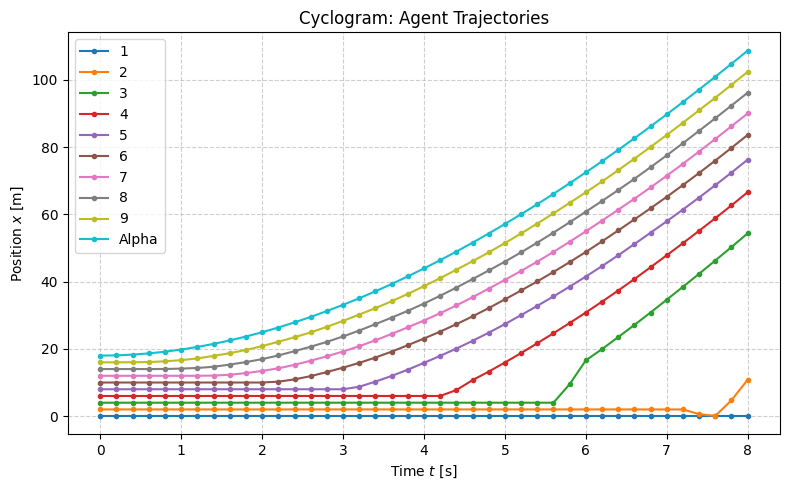

In [ ]:
N, s0, dt = 10, 2.0, 0.2
steps = 40
K = 8
generator = cyclic_sequences_efficient(N, K)

swarm = Swarm(N=N, s0=s0, dt=dt)
ctrl = SMDController(m=1676.0, a_max=3.7, v_d=33.3, s0=s0, dt=dt)

for _ in range(steps):
    bitmask = next(generator)
    acc = ctrl.control_step(swarm, bitmask)
    swarm.step(acc)
    if np.any(np.abs(np.diff(swarm.x)) < 1e-2): # столкнулись => стоп
      break

cyclogram(swarm)
plt.tight_layout()
plt.show()